In [ ]:
# cell-01 : Google Drive Mount (COLAB BUG SAFE VERSION)

from google.colab import drive
import os
import shutil

MOUNT_PATH = "/content/drive"

# If drive folder exists but is NOT a mount, delete it (Colab bug fix)
if os.path.exists(MOUNT_PATH) and not os.path.ismount(MOUNT_PATH):
    print("Removing stale /content/drive folder (Colab bug fix)")
    shutil.rmtree(MOUNT_PATH)

# Now mount safely
drive.mount(MOUNT_PATH)


Mounted at /content/drive


In [ ]:
#cell-02
import os
import glob
import random
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


Using device: cuda


In [ ]:
#cell-03
class COCOSegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir=None, transform=None, img_size=256, img_exts=(".jpg", ".jpeg", ".png")):
        """
        Expects images in image_dir (files ending with img_exts).
        Masks are expected in mask_dir with naming convention: <image_filename_without_ext>_mask.png
        If mask_dir is None or mask file not found, an empty mask (all zeros) will be returned.
        """
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.img_size = img_size

        # collect images
        images = []
        for ext in img_exts:
            images.extend(sorted(glob.glob(os.path.join(image_dir, f"*{ext}"))))
        self.images = images

        print(f"[Dataset] Found {len(self.images)} images in {image_dir}")
        if mask_dir is not None:
            print(f"[Dataset] Using mask directory: {mask_dir}")
        else:
            print(f"[Dataset] No mask directory provided; will use empty masks when missing.")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert("RGB")

        # mask path convention: <name>_mask.png
        img_name = os.path.splitext(os.path.basename(img_path))[0]
        mask = None
        if self.mask_dir is not None:
            # try png/jpg
            candidate_png = os.path.join(self.mask_dir, img_name + "_mask.png")
            candidate_jpg = os.path.join(self.mask_dir, img_name + "_mask.jpg")
            candidate_any = os.path.join(self.mask_dir, img_name + "*")  # fallback
            if os.path.exists(candidate_png):
                mask = Image.open(candidate_png).convert("L")
            elif os.path.exists(candidate_jpg):
                mask = Image.open(candidate_jpg).convert("L")
            else:
                # try to find files starting with img_name
                matches = glob.glob(os.path.join(self.mask_dir, img_name + "*"))
                if matches:
                    mask = Image.open(matches[0]).convert("L")

        if mask is None:
            # create empty mask (same size as image)
            mask = Image.new("L", image.size, 0)

        # Resize both
        image = image.resize((self.img_size, self.img_size))
        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)

        # To tensor
        image = transforms.ToTensor()(image)  # [C,H,W], float in [0,1]
        mask_np = np.array(mask).astype(np.uint8)
        mask_tensor = torch.from_numpy(mask_np).float()  # [H,W]
        mask_tensor = (mask_tensor > 0).float()  # binary 0/1

        return image, mask_tensor.unsqueeze(0)  # shape [1,H,W]


In [ ]:
#cell-04
class SimpleFCN(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(SimpleFCN, self).__init__()
        self.enc1 = self.conv_block(in_channels, 64)
        self.enc2 = self.conv_block(64, 128)
        self.enc3 = self.conv_block(128, 256)
        self.enc4 = self.conv_block(256, 512)
        self.pool = nn.MaxPool2d(2, 2)

        # Decoder (3 upsampling steps)
        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec1 = self.conv_block(256, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = self.conv_block(128, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec3 = self.conv_block(64, 64)

        self.out = nn.Conv2d(64, out_channels, 1)

    def conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        e1 = self.enc1(x)                 # 256x256
        e2 = self.enc2(self.pool(e1))     # 128x128
        e3 = self.enc3(self.pool(e2))     # 64x64
        e4 = self.enc4(self.pool(e3))     # 32x32

        d1 = self.dec1(self.up1(e4))      # 64x64
        d2 = self.dec2(self.up2(d1))      # 128x128
        d3 = self.dec3(self.up3(d2))      # 256x256

        out = self.out(d3)
        return torch.sigmoid(out)


class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(SimpleUNet, self).__init__()
        self.enc1 = self.conv_block(in_channels, 64)
        self.enc2 = self.conv_block(64, 128)
        self.enc3 = self.conv_block(128, 256)
        self.enc4 = self.conv_block(256, 512)
        self.pool = nn.MaxPool2d(2, 2)

        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec1 = self.conv_block(512, 256)  # cat => 512

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = self.conv_block(256, 128)  # cat => 256

        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec3 = self.conv_block(128, 64)   # cat => 128

        self.out = nn.Conv2d(64, out_channels, 1)

    def conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        d1 = self.up1(e4)
        d1 = torch.cat([d1, e3], dim=1)
        d1 = self.dec1(d1)

        d2 = self.up2(d1)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d3 = self.up3(d2)
        d3 = torch.cat([d3, e1], dim=1)
        d3 = self.dec3(d3)

        out = self.out(d3)
        return torch.sigmoid(out)


In [ ]:
#cell-05
def dice_loss(pred, target, smooth=1e-6):
    # pred, target: [B,1,H,W] with floats (pred in [0,1])
    pred = pred.contiguous()
    target = target.contiguous()
    intersection = (pred * target).sum(dim=2).sum(dim=2)  # shape [B,1]
    pred_sum = pred.sum(dim=2).sum(dim=2)
    target_sum = target.sum(dim=2).sum(dim=2)
    dice = (2. * intersection + smooth) / (pred_sum + target_sum + smooth)
    return 1 - dice.mean()

def iou_score(pred, target, threshold=0.5, eps=1e-6):
    # pred, target: tensors [B,1,H,W]
    pred_bin = (pred > threshold).float()
    inter = (pred_bin * target).sum(dim=(1,2,3))
    union = pred_bin.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) - inter
    iou = ((inter + eps) / (union + eps)).mean()
    return iou.item()


In [ ]:
#cell-06
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3, model_name="Model", output_dir=None):
    model = model.to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    val_ious = []

    print(f"\n{'='*40}\nTraining {model_name}\n{'='*40}")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        pbar = tqdm(train_loader, desc=f"{model_name} Train Epoch {epoch+1}/{epochs}", leave=False)
        for images, masks in pbar:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks) + dice_loss(outputs, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})

        train_loss = running_loss / max(1, len(train_loader))
        train_losses.append(train_loss)

        # Validation
        model.eval()
        running_val_loss = 0.0
        running_iou = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)
                loss = criterion(outputs, masks) + dice_loss(outputs, masks)
                running_val_loss += loss.item()
                running_iou += iou_score(outputs, masks)

        val_loss = running_val_loss / max(1, len(val_loader))
        val_iou = running_iou / max(1, len(val_loader))
        val_losses.append(val_loss)
        val_ious.append(val_iou)

        print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}  Val IoU: {val_iou:.4f}")

        # optional: save checkpoint each epoch
        if output_dir is not None:
            ckpt_path = os.path.join(output_dir, f"{model_name}_epoch{epoch+1}.pth")
            torch.save(model.state_dict(), ckpt_path)

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_ious": val_ious,
    }


In [ ]:
#cell-07
def visualize_predictions(model, dataset, output_dir, num_samples=3, model_name="model"):
    model.eval()
    os.makedirs(output_dir, exist_ok=True)
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

    for i in range(num_samples):
        idx = random.randint(0, len(dataset) - 1)
        image, mask = dataset[idx]  # image [C,H,W], mask [1,H,W]

        with torch.no_grad():
            input_tensor = image.unsqueeze(0).to(device)
            pred = model(input_tensor).cpu().squeeze(0)  # [1,H,W] or [H,W] depending

        # Ensure shape
        if pred.dim() == 3 and pred.shape[0] == 1:
            pred = pred.squeeze(0)

        image_np = image.permute(1, 2, 0).numpy()
        mask_np = mask.squeeze(0).numpy()
        pred_np = (pred.numpy() > 0.5).astype(float)

        axes[i, 0].imshow(image_np)
        axes[i, 0].set_title("Original Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask_np, cmap="gray")
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred_np, cmap="gray")
        axes[i, 2].set_title(f"{model_name} Prediction")
        axes[i, 2].axis("off")

    plt.tight_layout()
    save_path = os.path.join(output_dir, f"{model_name}_predictions.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Saved] {save_path}")
    return save_path


In [ ]:
#cell-08
def resolve_mask_dir(dataset_root, candidates=None):
    """
    Returns first existing mask dir from candidates. If none exist, returns None.
    """
    if candidates is None:
        candidates = [
            os.path.join(dataset_root, "train_masks"),
            os.path.join(dataset_root, "val_masks"),
            os.path.join(dataset_root, "masks"),
            os.path.join(dataset_root, "mask_train"),
            os.path.join(dataset_root, "mask_val"),
            os.path.join(dataset_root, "annotations"),
            os.path.join(dataset_root, "annotations", "masks"),
        ]
    for c in candidates:
        if os.path.exists(c) and os.path.isdir(c):
            return c
    return None


In [ ]:
#cell-09 (FINAL & CORRECT)

DATASET_ROOT = "/content/drive/MyDrive/infosys_internship/dataset"
OUTPUT_DIR = "/content/drive/MyDrive/ASSIGNMENT-02"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ===== CORRECT IMAGE DIRECTORIES (FROM YOUR SCREENSHOT) =====
TRAIN_IMG_DIR = os.path.join(DATASET_ROOT, "train2017", "train2017")
VAL_IMG_DIR   = os.path.join(DATASET_ROOT, "val2017", "val2017")

# ===== MASK DIRECTORIES (FROM ASSIGNMENT-01 OUTPUTS) =====
TRAIN_MASK_DIR = os.path.join(DATASET_ROOT, "train_masks")
VAL_MASK_DIR   = os.path.join(DATASET_ROOT, "val_masks")

# If masks don't exist, fallback safely
if not os.path.exists(TRAIN_MASK_DIR):
    TRAIN_MASK_DIR = None
if not os.path.exists(VAL_MASK_DIR):
    VAL_MASK_DIR = None

print("Resolved paths:")
print(" TRAIN_IMG_DIR:", TRAIN_IMG_DIR, "exists?", os.path.exists(TRAIN_IMG_DIR))
print(" VAL_IMG_DIR:  ", VAL_IMG_DIR, "exists?", os.path.exists(VAL_IMG_DIR))
print(" TRAIN_MASK_DIR:", TRAIN_MASK_DIR)
print(" VAL_MASK_DIR:  ", VAL_MASK_DIR)

# ===== HYPERPARAMETERS =====
IMG_SIZE = 128
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 0.001

# ===== CREATE DATASETS =====
train_dataset = COCOSegmentationDataset(
    image_dir=TRAIN_IMG_DIR,
    mask_dir=TRAIN_MASK_DIR,
    img_size=IMG_SIZE
)

val_dataset = COCOSegmentationDataset(
    image_dir=VAL_IMG_DIR,
    mask_dir=VAL_MASK_DIR,
    img_size=IMG_SIZE
)

# ===== SAFETY CHECK =====
if len(train_dataset) == 0 or len(val_dataset) == 0:
    raise ValueError("❌ Dataset empty — check image paths again.")

# ===== OPTIONAL SUBSET (FOR SPEED) =====
train_dataset.images = train_dataset.images[:500]
val_dataset.images   = val_dataset.images[:50]

print(f"Using {len(train_dataset)} training images")
print(f"Using {len(val_dataset)} validation images")

# ===== DATALOADERS =====
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(" DataLoaders created successfully")
print(" Outputs will be saved to:", OUTPUT_DIR)


Resolved paths:
 TRAIN_IMG_DIR: /content/drive/MyDrive/infosys_internship/dataset/train2017/train2017 exists? True
 VAL_IMG_DIR:   /content/drive/MyDrive/infosys_internship/dataset/val2017/val2017 exists? True
 TRAIN_MASK_DIR: None
 VAL_MASK_DIR:   None
[Dataset] Found 7171 images in /content/drive/MyDrive/infosys_internship/dataset/train2017/train2017
[Dataset] No mask directory provided; will use empty masks when missing.
[Dataset] Found 501 images in /content/drive/MyDrive/infosys_internship/dataset/val2017/val2017
[Dataset] No mask directory provided; will use empty masks when missing.
Using 500 training images
Using 50 validation images
 DataLoaders created successfully
 Outputs will be saved to: /content/drive/MyDrive/ASSIGNMENT-02


In [ ]:
#cell-10
print("\n" + "="*60)
print("TRAINING MODEL 1: SIMPLE FCN")
print("="*60)

fcn_model = SimpleFCN().to(device)
fcn_stats = train_model(
    fcn_model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    model_name="SimpleFCN",
    output_dir=OUTPUT_DIR
)

FCN_PATH = os.path.join(OUTPUT_DIR, "simple_fcn.pth")
torch.save(fcn_model.state_dict(), FCN_PATH)
print(f"[Saved] SimpleFCN final model: {FCN_PATH}")



TRAINING MODEL 1: SIMPLE FCN

Training SimpleFCN


Epoch [1/5] Train Loss: 1.2905  Val Loss: 1.1816  Val IoU: 1.0000


Epoch [2/5] Train Loss: 1.1237  Val Loss: 1.1006  Val IoU: 0.9531


Epoch [3/5] Train Loss: 1.0752  Val Loss: 1.0557  Val IoU: 1.0000


Epoch [4/5] Train Loss: 1.0447  Val Loss: 1.0360  Val IoU: 1.0000


Epoch [5/5] Train Loss: 1.0303  Val Loss: 1.0252  Val IoU: 1.0000
[Saved] SimpleFCN final model: /content/drive/MyDrive/ASSIGNMENT-02/simple_fcn.pth


In [ ]:
#cell-11
print("\n" + "="*60)
print("TRAINING MODEL 2: SIMPLE U-NET")
print("="*60)

unet_model = SimpleUNet().to(device)
unet_stats = train_model(
    unet_model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    model_name="SimpleUNet",
    output_dir=OUTPUT_DIR
)

UNET_PATH = os.path.join(OUTPUT_DIR, "simple_unet.pth")
torch.save(unet_model.state_dict(), UNET_PATH)
print(f"[Saved] SimpleUNet final model: {UNET_PATH}")



TRAINING MODEL 2: SIMPLE U-NET

Training SimpleUNet


Epoch [1/5] Train Loss: 1.3085  Val Loss: 1.2293  Val IoU: 1.0000


Epoch [2/5] Train Loss: 1.1355  Val Loss: 1.1408  Val IoU: 0.7812


Epoch [3/5] Train Loss: 1.0784  Val Loss: 1.0679  Val IoU: 0.7969


Epoch [4/5] Train Loss: 1.0505  Val Loss: 1.0398  Val IoU: 1.0000


Epoch [5/5] Train Loss: 1.0344  Val Loss: 1.0287  Val IoU: 1.0000
[Saved] SimpleUNet final model: /content/drive/MyDrive/ASSIGNMENT-02/simple_unet.pth


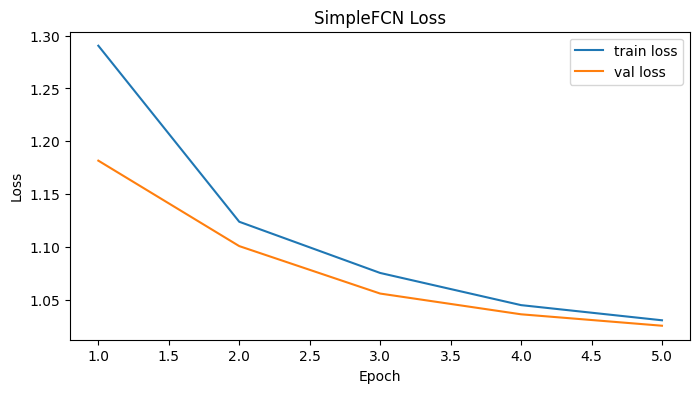

[Saved] /content/drive/MyDrive/ASSIGNMENT-02/SimpleFCN_loss.png


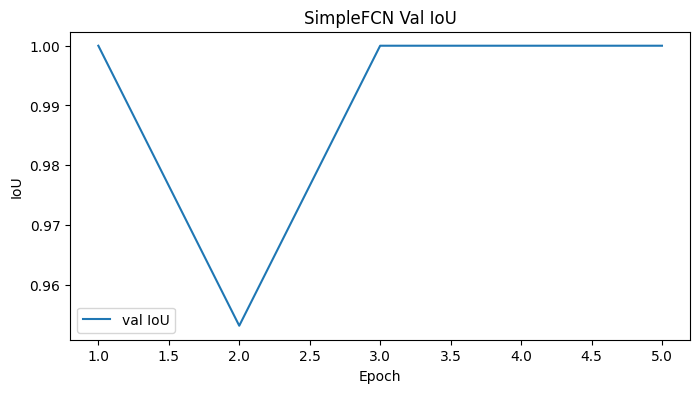

[Saved] /content/drive/MyDrive/ASSIGNMENT-02/SimpleFCN_iou.png


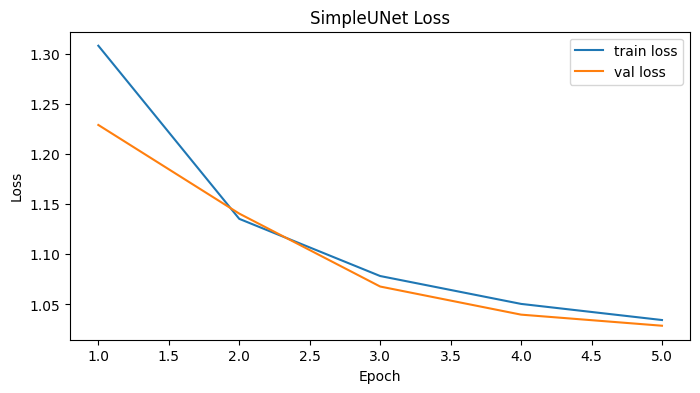

[Saved] /content/drive/MyDrive/ASSIGNMENT-02/SimpleUNet_loss.png


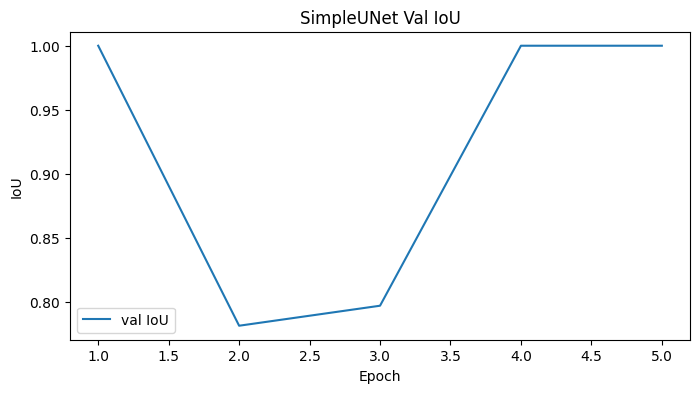

[Saved] /content/drive/MyDrive/ASSIGNMENT-02/SimpleUNet_iou.png


In [ ]:
#cell-12
# plot loss curves and IoU for both models
def plot_training_stats(stats, model_name, output_dir):
    epochs = len(stats["train_losses"])
    plt.figure(figsize=(8,4))
    plt.plot(range(1, epochs+1), stats["train_losses"], label="train loss")
    plt.plot(range(1, epochs+1), stats["val_losses"], label="val loss")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    p = os.path.join(output_dir, f"{model_name}_loss.png")
    plt.savefig(p, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Saved] {p}")

    plt.figure(figsize=(8,4))
    plt.plot(range(1, epochs+1), stats["val_ious"], label="val IoU")
    plt.title(f"{model_name} Val IoU")
    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.legend()
    p2 = os.path.join(output_dir, f"{model_name}_iou.png")
    plt.savefig(p2, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Saved] {p2}")

# Save plots for both
plot_training_stats(fcn_stats, "SimpleFCN", OUTPUT_DIR)
plot_training_stats(unet_stats, "SimpleUNet", OUTPUT_DIR)


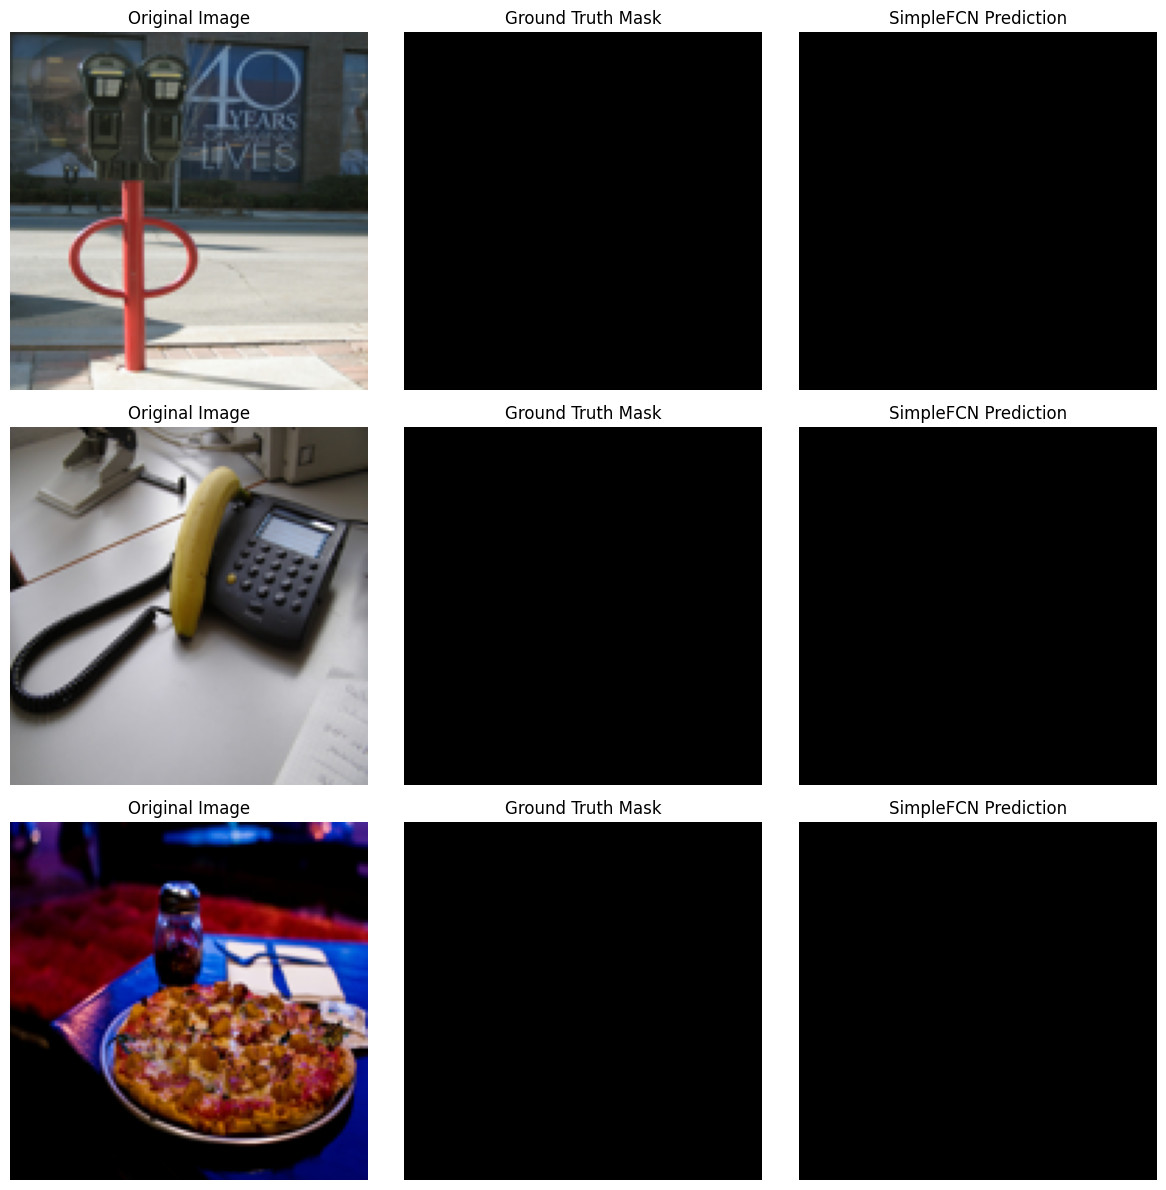

[Saved] /content/drive/MyDrive/ASSIGNMENT-02/SimpleFCN_predictions.png


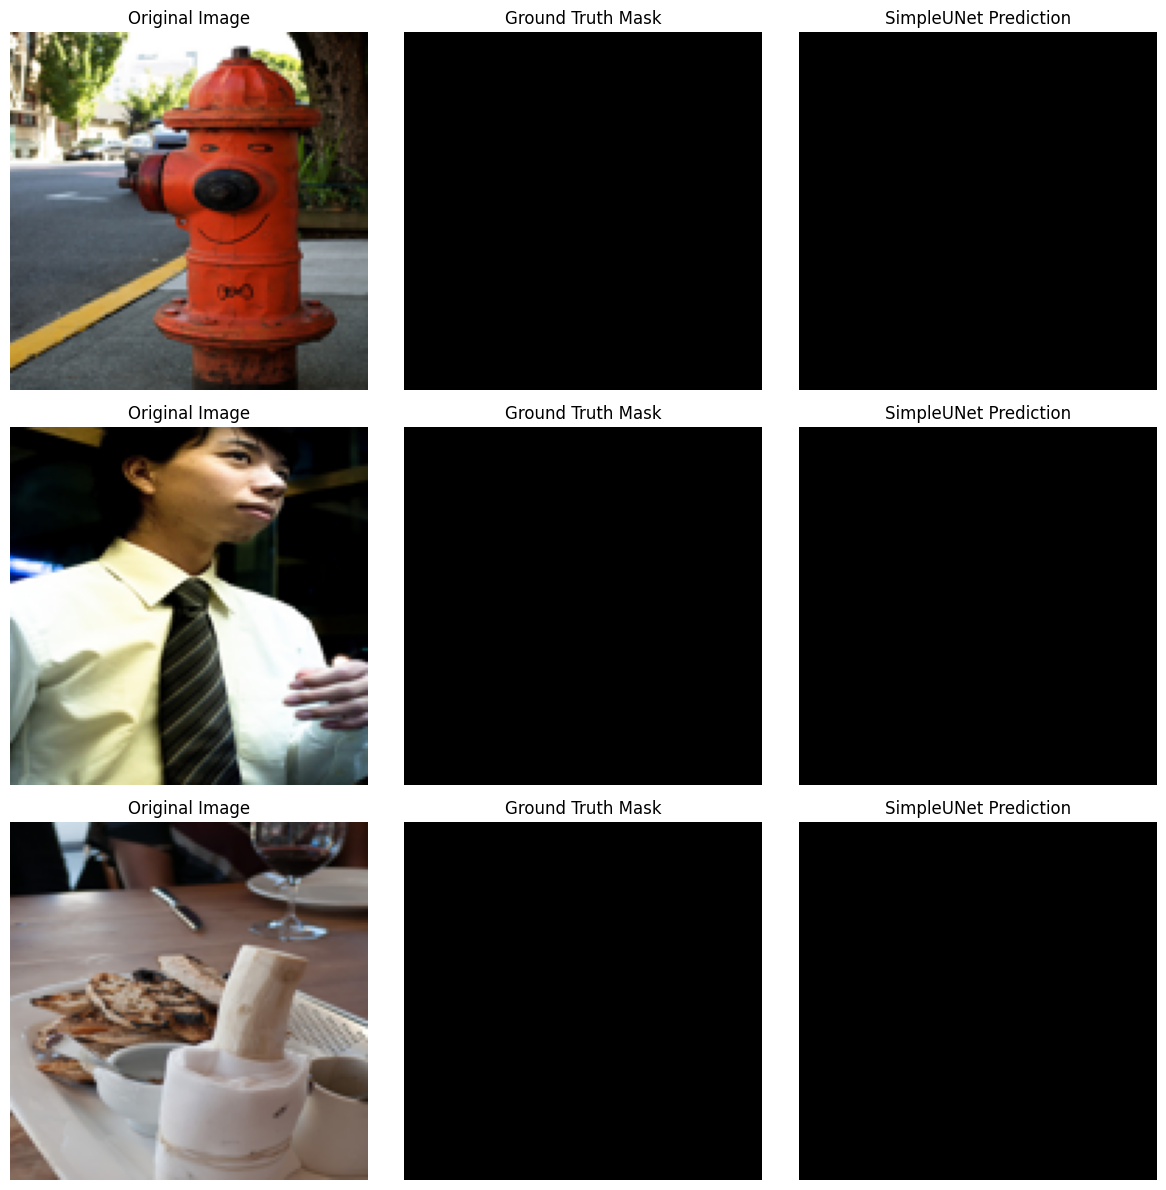

[Saved] /content/drive/MyDrive/ASSIGNMENT-02/SimpleUNet_predictions.png

All done. Models, plots, and prediction images are saved in:
/content/drive/MyDrive/ASSIGNMENT-02


In [ ]:
#cell-13
# Ensure models are in eval mode
fcn_model.eval()
unet_model.eval()

# Visualize a few predictions and save into OUTPUT_DIR
visualize_predictions(fcn_model, val_dataset, output_dir=OUTPUT_DIR, num_samples=3, model_name="SimpleFCN")
visualize_predictions(unet_model, val_dataset, output_dir=OUTPUT_DIR, num_samples=3, model_name="SimpleUNet")

print("\nAll done. Models, plots, and prediction images are saved in:")
print(OUTPUT_DIR)
